### Import Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Import DataSet

In [2]:
data = pd.read_csv('Data/data.csv')

### Information About DataSet

In [3]:
data.head()

,TV,Radio,Newspaper,Sales
0,102,25,34,8.76
1,270,38,45,17.85
2,106,78,12,11.92
3,71,41,67,10.43
4,188,12,23,11.76


In [4]:
data.shape

(116, 4)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         116 non-null    int64  
 1   Radio      116 non-null    int64  
 2   Newspaper  116 non-null    int64  
 3   Sales      116 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 3.8 KB


In [6]:
data.describe()

,TV,Radio,Newspaper,Sales
count,116.000000,116.000000,116.000000,116.000000
mean,167.655172,49.586207,40.198276,13.209914
std,79.927914,20.933048,15.110733,3.105242
min,20.000000,10.000000,10.000000,6.500000
25%,98.000000,33.750000,30.000000,10.937500
50%,167.500000,50.000000,40.000000,12.975000
75%,230.000000,65.000000,50.000000,15.400000
max,320.000000,90.000000,70.000000,20.000000


### Checking and Processing NULL Values

In [7]:
data.isna().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

### Relation between TV ads and Sales

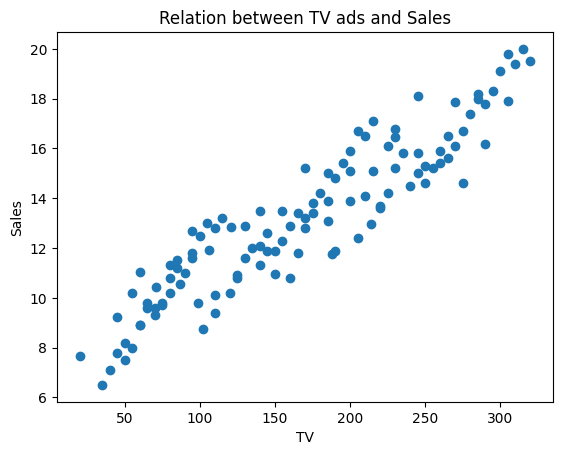

In [8]:
plt.scatter(data['TV'], data['Sales'])
plt.title('Relation between TV ads and Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

### Relation between Radio ads and Sales

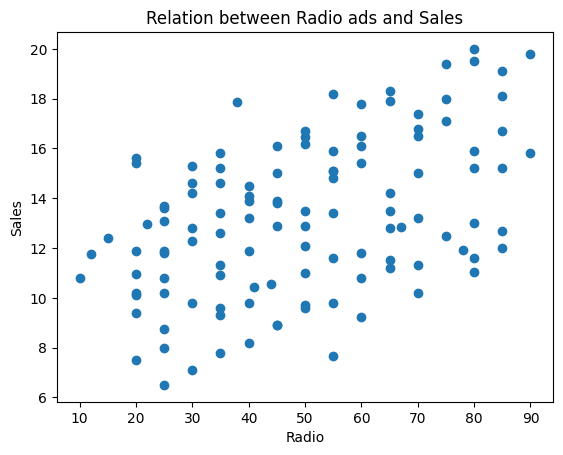

In [9]:
plt.scatter(data['Radio'], data['Sales'])
plt.title('Relation between Radio ads and Sales')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.show()

### Relation between Newspaper ads and Sales

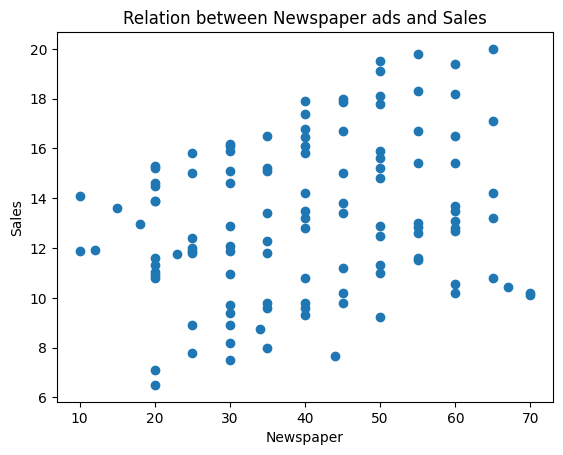

In [10]:
plt.scatter(data['Newspaper'], data['Sales'])
plt.title('Relation between Newspaper ads and Sales')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.show()

### Separate DataSet into Independent and Dependent Variable 

In [11]:
X = data.drop('Sales', axis = 1)
y = data['Sales']

### Split DataSet into Training and Testing DataSet

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Apply Lasso Algorithm

In [13]:
from sklearn.linear_model import Lasso
model = Lasso()
model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Testing the Model

In [14]:
y_pred = model.predict(X_test)

### Calculate r2 Score

In [15]:
from sklearn.metrics import r2_score
r2 = r2_score(y_pred, y_test)
print('Accuracy of this Model is', round(r2*100,2))

Accuracy of this Model is 96.25


### Creating Pickle File

In [16]:
import joblib
joblib.dump(model, '../../Model/Sales by Medium Predictor by Lasso.pkl')
print('Model Saved Succesfully')

Model Saved Succesfully


### Get Coefficient

In [17]:
features = X.columns
print(features)

Index(['TV', 'Radio', 'Newspaper'], dtype='object')


In [18]:
coefficients = model.coef_
print(coefficients.round(4))

[0.0336 0.0418 0.0238]


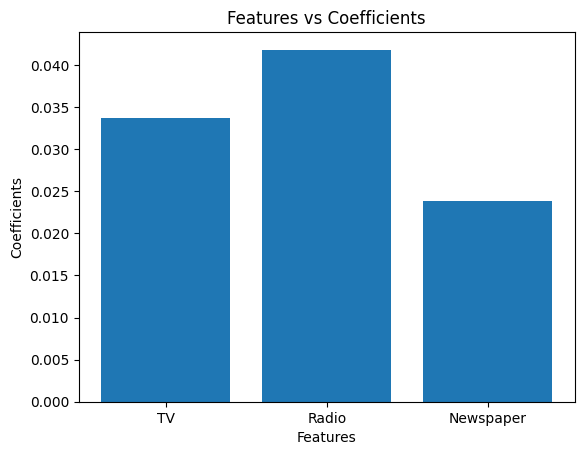

In [19]:
plt.bar(features, coefficients)
plt.title('Features vs Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.show()